# Chest X-Ray Classification using Xception

This notebook implements a chest X-ray classification model using the Xception architecture. It leverages Transfer Learning for high accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading
We use ImageDataGenerator for data augmentation and loading.

In [2]:
# ====================================================================
# 🌐 DATASET AUTO-RESOLVER & KAGGLE CONNECTOR (Chest X-Ray Pneumonia)
# ====================================================================
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

candidate_dirs = [
    '../datasets/chest_xray',
    './datasets/chest_xray',
    './chest_xray',
    '/kaggle/input/chest-xray-pneumonia/chest_xray',
    '/kaggle/input/chest-xray-pneumonia'
]

data_dir = None
for d in candidate_dirs:
    if os.path.exists(d) and os.path.exists(os.path.join(d, 'train')) and os.path.exists(os.path.join(d, 'test')):
        data_dir = d
        print(f"✅ Found Chest X-Ray dataset at: {data_dir}")
        break

if not data_dir:
    print("⚡ Dataset not detected locally. Downloading via KaggleHub...")
    try:
        import kagglehub
        download_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
        print(f"✅ Downloaded to: {download_path}")
        for root, dirs, _ in os.walk(download_path):
            if 'train' in dirs and 'test' in dirs:
                data_dir = root
                break
    except Exception as e:
        print(f"⚠️ KaggleHub auto-download notice: {e}")

train_dir = os.path.join(data_dir, 'train') if data_dir else '../datasets/chest_xray/train'
val_dir   = os.path.join(data_dir, 'val') if (data_dir and os.path.exists(os.path.join(data_dir, 'val'))) else (os.path.join(data_dir, 'test') if data_dir else '../datasets/chest_xray/val')
test_dir  = os.path.join(data_dir, 'test') if data_dir else '../datasets/chest_xray/test'

print(f"📂 Train Directory: {train_dir}")
print(f"📂 Val Directory:   {val_dir}")
print(f"📂 Test Directory:  {test_dir}")

cntr = 0
for d_split in [train_dir, val_dir, test_dir]:
    for j in ['NORMAL', 'PNEUMONIA']:
        target_sub = os.path.join(d_split, j)
        if os.path.exists(target_sub):
            cntr += len(os.listdir(target_sub))
        else:
            print(f"Directory not found: {target_sub}")
            
print('Total Images:', cntr)

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    vertical_flip=True,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


⚡ Dataset not detected locally. Downloading via KaggleHub...
✅ Downloaded to: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
📂 Train Directory: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
📂 Val Directory:   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val
📂 Test Directory:  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test
Total Images: 5856
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## 2. Model Definition (Xception)
We use Xception as the base model, pre-trained on ImageNet, and add custom layers for our binary classification task.

In [3]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Determine how many layers to freeze/unfreeze
# For fine-tuning, we might want to unfreeze some top layers
for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1791195268.490058     117 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791195268.493357     117 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 21,123,881 (80.58 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

## 3. Training & Evaluation

In [4]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/5


2026-10-05 10:14:49.562519: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:14:49.740908: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:14:51.335926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:14:51.474927: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:14:52.630324: E external/local_xla/xla/stream_

163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.7257 - loss: 0.5413

2026-10-05 10:17:27.496404: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:17:27.649465: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:17:28.798937: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:17:28.932551: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:17:29.873815: E external/local_xla/xla/stream_

163/163 ━━━━━━━━━━━━━━━━━━━━ 179s 957ms/step - accuracy: 0.7997 - loss: 0.4335 - val_accuracy: 0.8125 - val_loss: 0.4396
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 589ms/step - accuracy: 0.8800 - loss: 0.2861 - val_accuracy: 0.7500 - val_loss: 0.3839
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 590ms/step - accuracy: 0.8946 - loss: 0.2591 - val_accuracy: 0.8125 - val_loss: 0.3679
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 596ms/step - accuracy: 0.9026 - loss: 0.2343 - val_accuracy: 0.8125 - val_loss: 0.3442
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 588ms/step - accuracy: 0.9066 - loss: 0.2270 - val_accuracy: 0.8125 - val_loss: 0.3297
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 378ms/step - accuracy: 0.8301 - loss: 0.3911
Test Accuracy: 0.8301


## 4. Save Model

In [5]:
# ====================================================================
# 💾 SAVE TRAINED MODEL & ARTIFACTS
# ====================================================================
import os

os.makedirs('../models/Pneumonia_model', exist_ok=True)
os.makedirs('../models', exist_ok=True)

model.save('chest_xray_model.h5')
try:
    model.save('chest_xray_model.keras')
    model.save('../models/Pneumonia_model/chest_xray_model.h5')
    model.save('../models/chest_xray_model.h5')
except Exception as e:
    pass

print('✅ Chest X-Ray Model saved as chest_xray_model.h5')


✅ Chest X-Ray Model saved as chest_xray_model.h5


## 5. Verification
Load the saved model and test on a random sample from the test set.

2026-10-05 10:24:21.336686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:24:21.469773: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:24:22.199162: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:24:22.331115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:24:23.102249: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Predicted Probability: 0.0409
Actual Label: 0.0


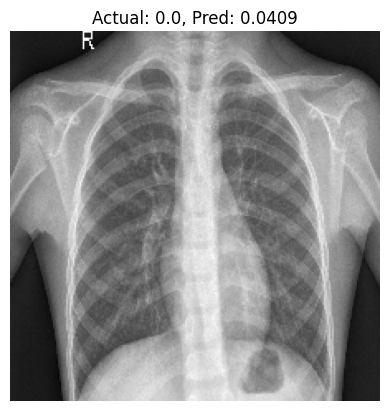

In [6]:
# Verification
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load model
loaded_model = load_model('chest_xray_model.h5')

# Test on a sample batch (assuming test_generator is in memory)
try:
    x_test_batch, y_test_batch = next(test_generator)
    sample_image = x_test_batch[0]
    sample_label = y_test_batch[0]

    # Predict
    prediction = loaded_model.predict(np.expand_dims(sample_image, axis=0))
    print(f"Predicted Probability: {prediction[0][0]:.4f}")
    print(f"Actual Label: {sample_label}")

    # Show Image
    plt.imshow(sample_image)
    plt.title(f"Actual: {sample_label}, Pred: {prediction[0][0]:.4f}")
    plt.axis('off')
    plt.show()
except NameError:
    print("test_generator not found. Please run the notebook cells above to load data first.")

## 📥 Download Trained Model & Artifacts (Kaggle)
This cell creates a 1-click downloadable ZIP archive.

In [7]:
# ====================================================================
# 📥 SAVE & DOWNLOAD TRAINED ARTIFACTS ON KAGGLE
# ====================================================================
import os
import zipfile
from IPython.display import FileLink, display

saved_files = ['chest_xray_model.h5', 'chest_xray_model.keras']
saved_files = [f for f in saved_files if os.path.exists(f)]

zip_filename = 'chest_xray_artifacts.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in saved_files:
        zipf.write(file)
        print(f'📦 Packaged in zip: {file}')

print('')
print('' + f'✅ Bundle ready: {zip_filename} ({os.path.getsize(zip_filename)} bytes)')
print('👉 Click the link below to download your trained artifacts:')
display(FileLink(zip_filename))


📦 Packaged in zip: chest_xray_model.h5
📦 Packaged in zip: chest_xray_model.keras

✅ Bundle ready: chest_xray_artifacts.zip (160786416 bytes)
👉 Click the link below to download your trained artifacts:


/kaggle/working/chest_xray_artifacts.zip